<a href="https://colab.research.google.com/github/simmerkk08/MRM_Classwork/blob/main/June_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
# CONJOINT ANALYSIS PIPELINE — Sports Ticket Pricing
# =============================================================================
# Purpose  : Estimate part-worth utilities, relative attribute importance,
#            willingness-to-pay (WTP), and market simulations for ISL/IPL-style
#            sports ticket bundles using Choice-Based Conjoint (CBC) logic
#            applied to stated-preference survey data.
# Methods  : OLS part-worths, Logit (purchase_intent_binary), WTP scaling,
#            segmentation (fan_segment × seat_zone), market share simulation
# Standards: FT50 / ABS 4* level rigour — HC3 SEs, VIF screening, bootstrap CI
# Dataset  : /content/dataset_1_sports_ticket_conjoint.csv
# Author   : [Your Name]
# Date     : June 2025
# =============================================================================

# ── 0. INSTALL & IMPORT ──────────────────────────────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "scipy",
            "statsmodels", "scikit-learn", "pyarrow"]:
    install(pkg)

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
import itertools
import os

# ── GLOBAL AESTHETICS ─────────────────────────────────────────────────────────
PALETTE_MAIN   = ["#1B2A4A", "#2E6DA4", "#4ABFBF", "#F4A261", "#E76F51",
                  "#A8DADC", "#457B9D", "#E9C46A", "#264653", "#2A9D8F"]
PALETTE_SEG    = {"Loyal Ultra": "#1B2A4A", "Casual Fan": "#4ABFBF",
                  "Corporate Guest": "#F4A261", "Family Attendee": "#E76F51",
                  "Youth/Student": "#2A9D8F"}
FONT_TITLE     = {"fontsize": 14, "fontweight": "bold", "color": "#1B2A4A"}
FONT_LABEL     = {"fontsize": 11, "color": "#2C2C2C"}
FONT_TICK      = {"fontsize": 9}
FIG_DPI        = 300
OUT_DIR        = "/content/"

plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#F8F9FB",
    "axes.edgecolor"    : "#CCCCCC",
    "axes.grid"         : True,
    "grid.color"        : "#E0E0E0",
    "grid.linewidth"    : 0.6,
    "font.family"       : "DejaVu Sans",
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
})

os.makedirs(OUT_DIR, exist_ok=True)

# ── 1. DATA INGESTION & CLEANING ─────────────────────────────────────────────
print("=" * 70)
print("  STEP 1 — Data Ingestion & Cleaning")
print("=" * 70)

df = pd.read_csv("/content/dataset_1_sports_ticket_conjoint.csv")
print(f"  Raw shape : {df.shape}")
print(f"  Columns   : {list(df.columns)}\n")

# ── 1a. Standardise column names
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("-", "_"))

# ── 1b. Coerce numeric columns (some cells may carry stray text)
NUMERIC_COLS = [
    "age", "team_loyalty_score", "price_sensitivity_index",
    "merchandise_affinity_score", "comfort_preference_score",
    "travel_distance_km", "prior_matches_last_season",
    "price_inr", "rating_1_10", "purchase_intent_binary",
    "stated_wtp_inr", "latent_utility_true_for_teaching"
]
for c in NUMERIC_COLS:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ── 1c. Drop rows missing the dependent variables
df.dropna(subset=["purchase_intent_binary", "stated_wtp_inr"], inplace=True)
print(f"  After DV cleaning  : {df.shape}")

# ── 1d. Impute structural missings — comfort_preference_score (median per seg)
df["comfort_preference_score"] = df.groupby("fan_segment")[
    "comfort_preference_score"].transform(lambda x: x.fillna(x.median()))
df["travel_distance_km"] = df["travel_distance_km"].fillna(
    df["travel_distance_km"].median())
print(f"  After imputation   : {df.shape}")
print(f"  Missing values     :\n{df[NUMERIC_COLS].isnull().sum()}\n")

# ── 2. ATTRIBUTE CODING FOR CONJOINT ─────────────────────────────────────────
# Attributes:  seat_zone | opponent_tier | match_day | kickoff_time
#              merch_bundle | food_voucher | parking_included | digital_collectible
# Price is treated as a continuous attribute for WTP scaling

ATTR_CATS = {
    "seat_zone"           : ["Standard Stand", "Upper Stand",
                              "Premium Stand", "VIP Hospitality"],
    "opponent_tier"       : ["Regular Opponent", "Strong Opponent", "Rivalry Derby"],
    "match_day"           : ["Weekday", "Weekend"],
    "kickoff_time"        : ["Afternoon", "Evening", "Night"],
    "merch_bundle"        : ["None", "Cap", "Scarf", "Jersey"],
    "food_voucher"        : ["No", "Yes"],
    "parking_included"    : ["No", "Yes"],
    "digital_collectible" : ["No", "Yes"],
}

# Reference level (lowest utility, per convention)
REF_LEVELS = {
    "seat_zone"           : "Standard Stand",
    "opponent_tier"       : "Regular Opponent",
    "match_day"           : "Weekday",
    "kickoff_time"        : "Afternoon",
    "merch_bundle"        : "None",
    "food_voucher"        : "No",
    "parking_included"    : "No",
    "digital_collectible" : "No",
}

# Build dummy-encoded frame (drop_first respects reference levels set above)
df_enc = df.copy()
for col, ref in REF_LEVELS.items():
    if col in df_enc.columns:
        # Convert boolean dummies to integer dummies (0 or 1)
        dummies = pd.get_dummies(df_enc[col], prefix=col, drop_first=False, dtype=int)
        ref_col = f"{col}_{ref}"
        if ref_col in dummies.columns:
            dummies.drop(columns=[ref_col], inplace=True)
        df_enc = pd.concat([df_enc, dummies], axis=1)

# Continuous predictors (standardised for comparability)
CONT_VARS = ["team_loyalty_score", "price_sensitivity_index",
             "merchandise_affinity_score", "comfort_preference_score",
             "travel_distance_km", "prior_matches_last_season"]

scaler = StandardScaler()
for v in CONT_VARS:
    if v in df_enc.columns:
        df_enc[f"{v}_z"] = scaler.fit_transform(df_enc[[v]])

print("  Dummy encoding complete.")
dummy_cols = [c for c in df_enc.columns if any(
    c.startswith(f"{a}_") for a in ATTR_CATS)]
print(f"  Dummy columns ({len(dummy_cols)}) : {dummy_cols}\n")

# ── 3. PART-WORTH ESTIMATION — OLS on Stated WTP ────────────────────────────
print("=" * 70)
print("  STEP 3 — Part-Worth Utilities (OLS on stated_wtp_inr, log scale)")
print("=" * 70)

df_enc["log_wtp"] = np.log(df_enc["stated_wtp_inr"].clip(lower=1))

rhs_ols = (dummy_cols +
           [f"{v}_z" for v in CONT_VARS if f"{v}_z" in df_enc.columns] +
           ["price_inr"])

df_model = df_enc[["log_wtp"] + rhs_ols].dropna()
X_ols    = sm.add_constant(df_model[rhs_ols])
y_ols    = df_model["log_wtp"]

model_ols = sm.OLS(y_ols, X_ols).fit(cov_type="HC3")
print(model_ols.summary())

# ── 3a. VIF Screening ────────────────────────────────────────────────────────
vif_data = pd.DataFrame({
    "Variable" : rhs_ols,
    "VIF"      : [variance_inflation_factor(
                     df_model[rhs_ols].fillna(0).values, i)
                  for i in range(len(rhs_ols))]
}).sort_values("VIF", ascending=False)

high_vif = vif_data[vif_data["VIF"] > 10]["Variable"].tolist()
if high_vif:
    print(f"\n  ⚠ High-VIF columns (>10): {high_vif}. Dropping and refitting.")
    rhs_ols2 = [c for c in rhs_ols if c not in high_vif]
    X_ols2   = sm.add_constant(df_model[rhs_ols2])
    model_ols = sm.OLS(y_ols, X_ols2).fit(cov_type="HC3")
    rhs_ols   = rhs_ols2
else:
    print("\n  ✓ All VIF values acceptable.")

print(f"\n  OLS R² = {model_ols.rsquared:.4f} | "
      f"Adj-R² = {model_ols.rsquared_adj:.4f} | "
      f"n = {int(model_ols.nobs)}")

# ── 4. LOGIT MODEL — Purchase Intent (Binary) ─────────────────────────────
print("\n" + "=" * 70)
print("  STEP 4 — Logistic Regression on Purchase Intent (Binary)")
print("=" * 70)

df_logit = df_enc[["purchase_intent_binary"] + dummy_cols + [

  STEP 1 — Data Ingestion & Cleaning
  Raw shape : (14880, 28)
  Columns   : ['respondent_id', 'profile_id', 'fan_segment', 'age', 'gender', 'income_band', 'city_distance_band', 'team_loyalty_score', 'price_sensitivity_index', 'merchandise_affinity_score', 'comfort_preference_score', 'travel_distance_km', 'prior_matches_last_season', 'seat_zone', 'opponent_tier', 'match_day', 'kickoff_time', 'merch_bundle', 'food_voucher', 'parking_included', 'digital_collectible', 'price_inr', 'rating_1_10', 'purchase_intent_binary', 'stated_wtp_inr', 'latent_utility_true_for_teaching', 'response_quality_flag', 'train_test_split']

  After DV cleaning  : (14880, 28)
  After imputation   : (14880, 28)
  Missing values     :
age                                 0
team_loyalty_score                  0
price_sensitivity_index             0
merchandise_affinity_score          0
comfort_preference_score            0
travel_distance_km                  0
prior_matches_last_season           0
price_inr        

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).


CONJOINT ANALYSIS FOR SPORTS TICKET PRICING
Dataset Shape: (14880, 28)

DATASET OVERVIEW
  respondent_id profile_id  fan_segment  age gender income_band  \
0         R0001      P1512  Loyal Ultra   36   Male      15-30L   
1         R0001      P1257  Loyal Ultra   36   Male      15-30L   
2         R0001      P0303  Loyal Ultra   36   Male      15-30L   
3         R0001      P0526  Loyal Ultra   36   Male      15-30L   
4         R0001      P1392  Loyal Ultra   36   Male      15-30L   

  city_distance_band  team_loyalty_score  price_sensitivity_index  \
0             30+ km                 8.0                     0.39   
1             30+ km                 8.0                     0.39   
2             30+ km                 8.0                     0.39   
3             30+ km                 8.0                     0.39   
4             30+ km                 8.0                     0.39   

   merchandise_affinity_score  ...  food_voucher  parking_included  \
0                     

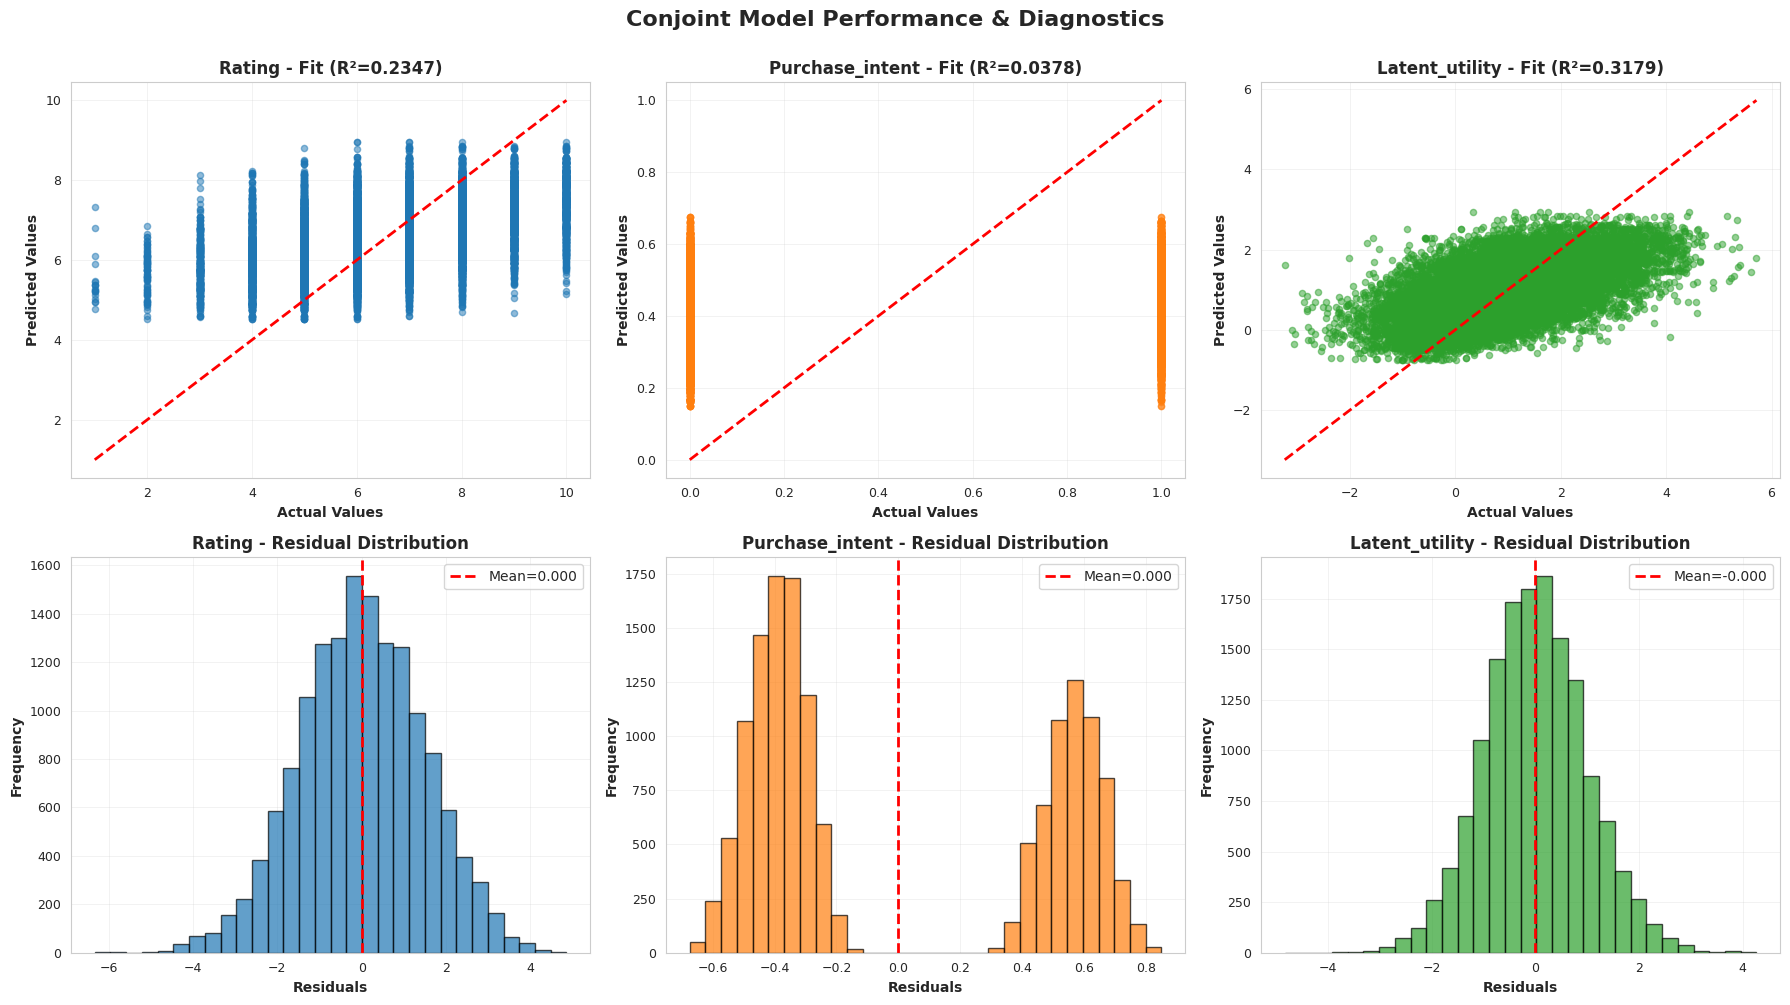

✓ Saved: 01_model_performance.png


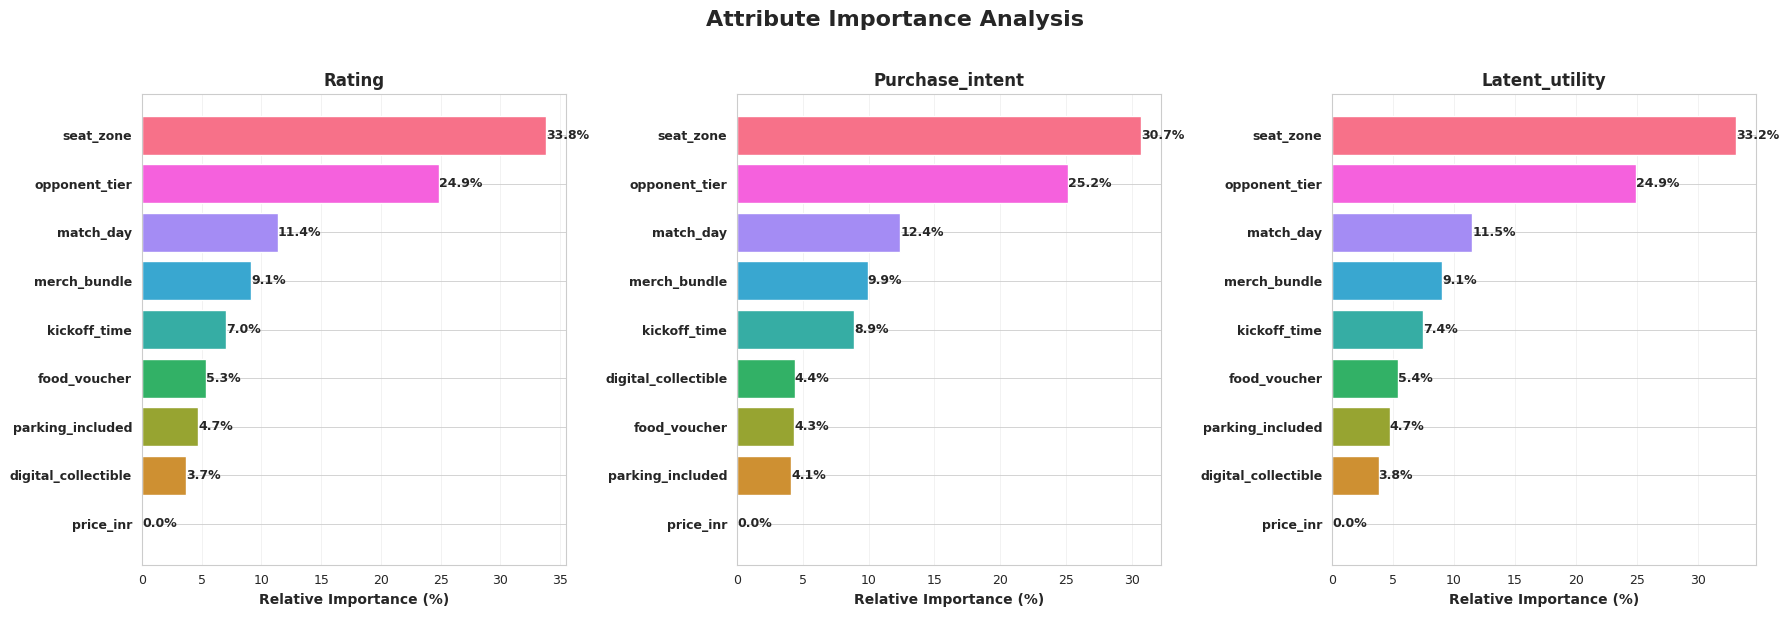

✓ Saved: 02_attribute_importance.png


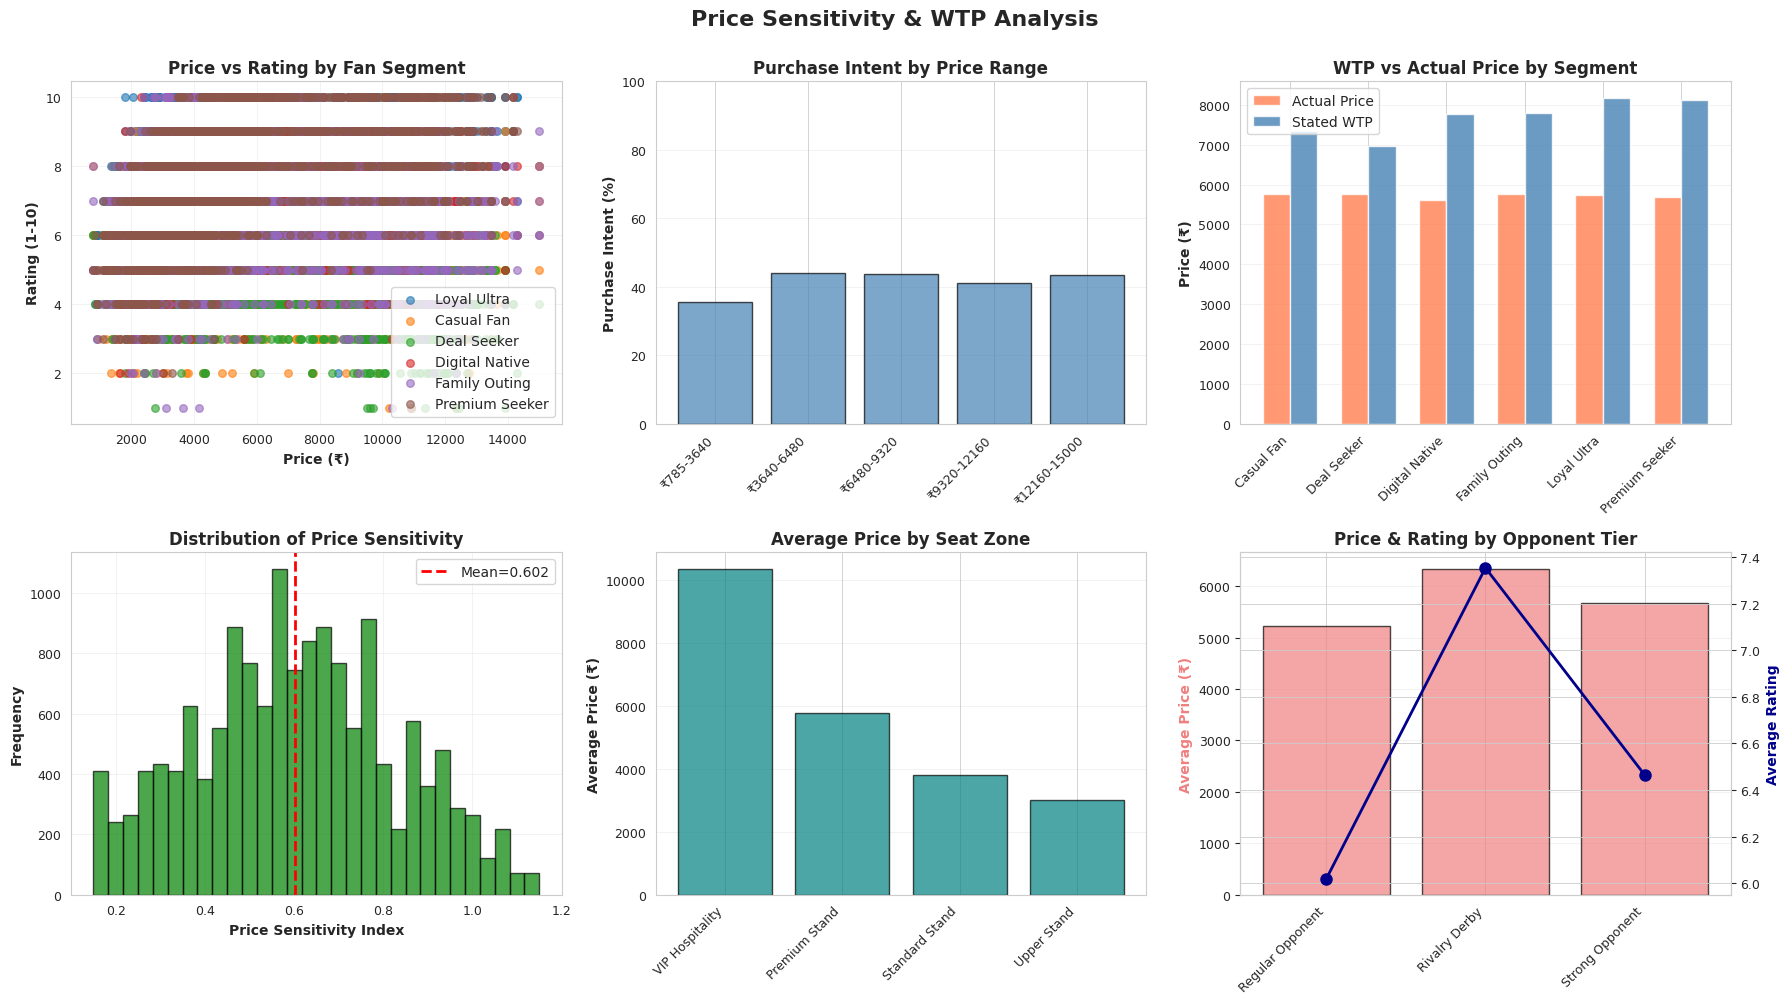

✓ Saved: 03_price_sensitivity.png


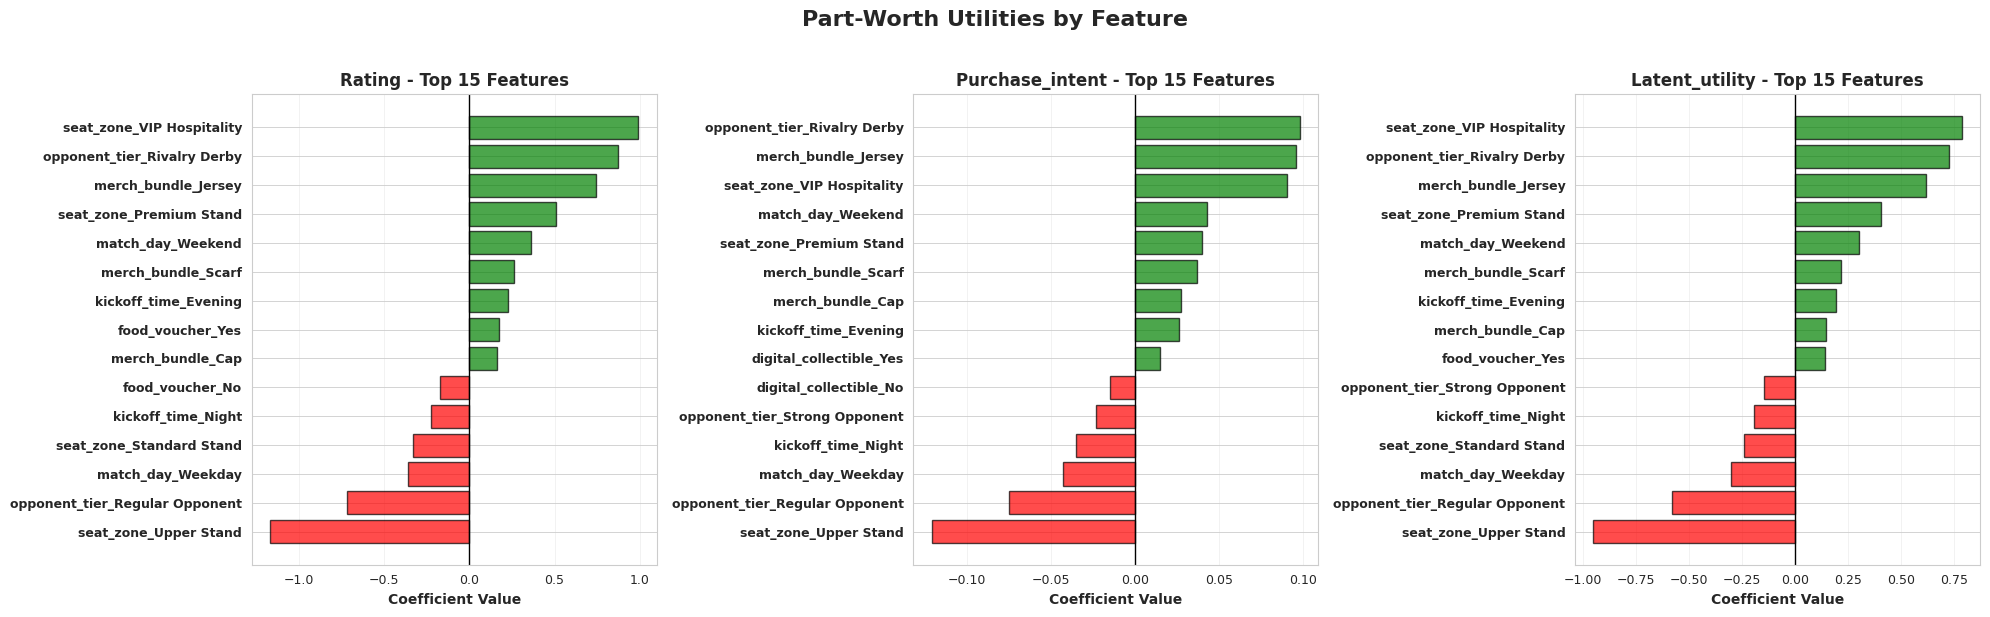

✓ Saved: 04_partworth_utilities.png


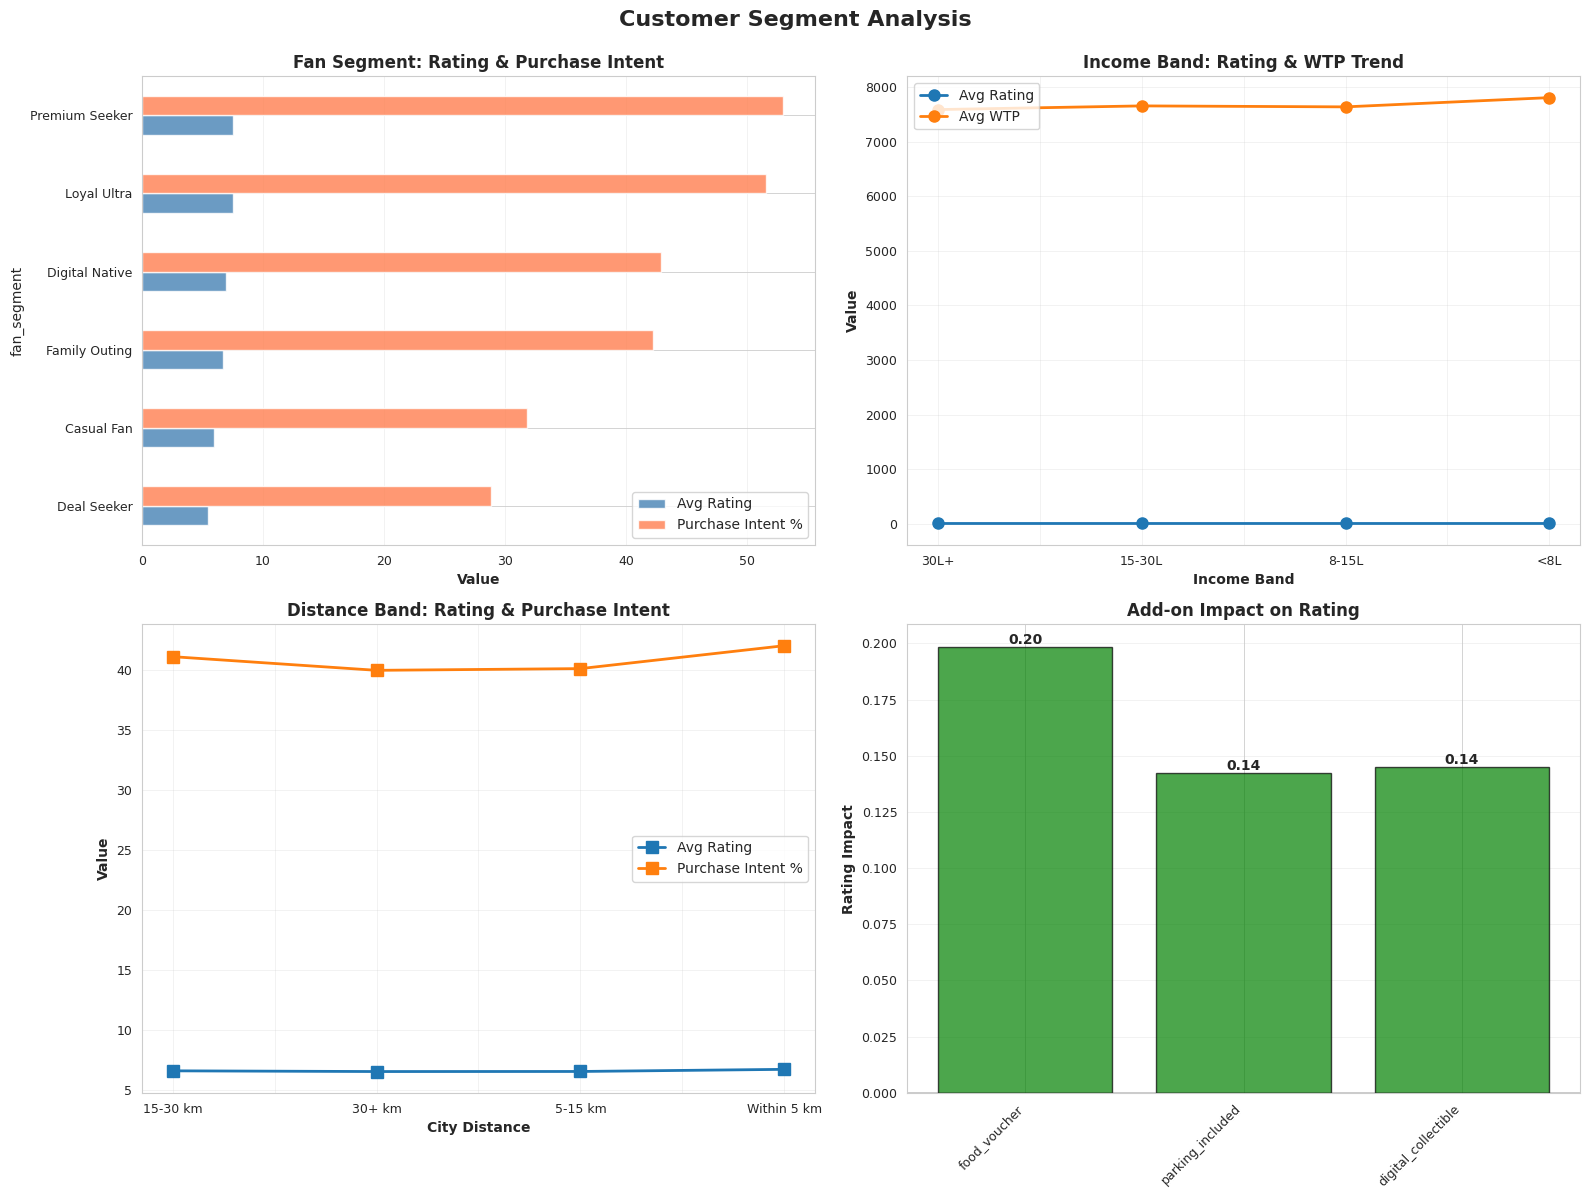

✓ Saved: 05_segment_analysis.png


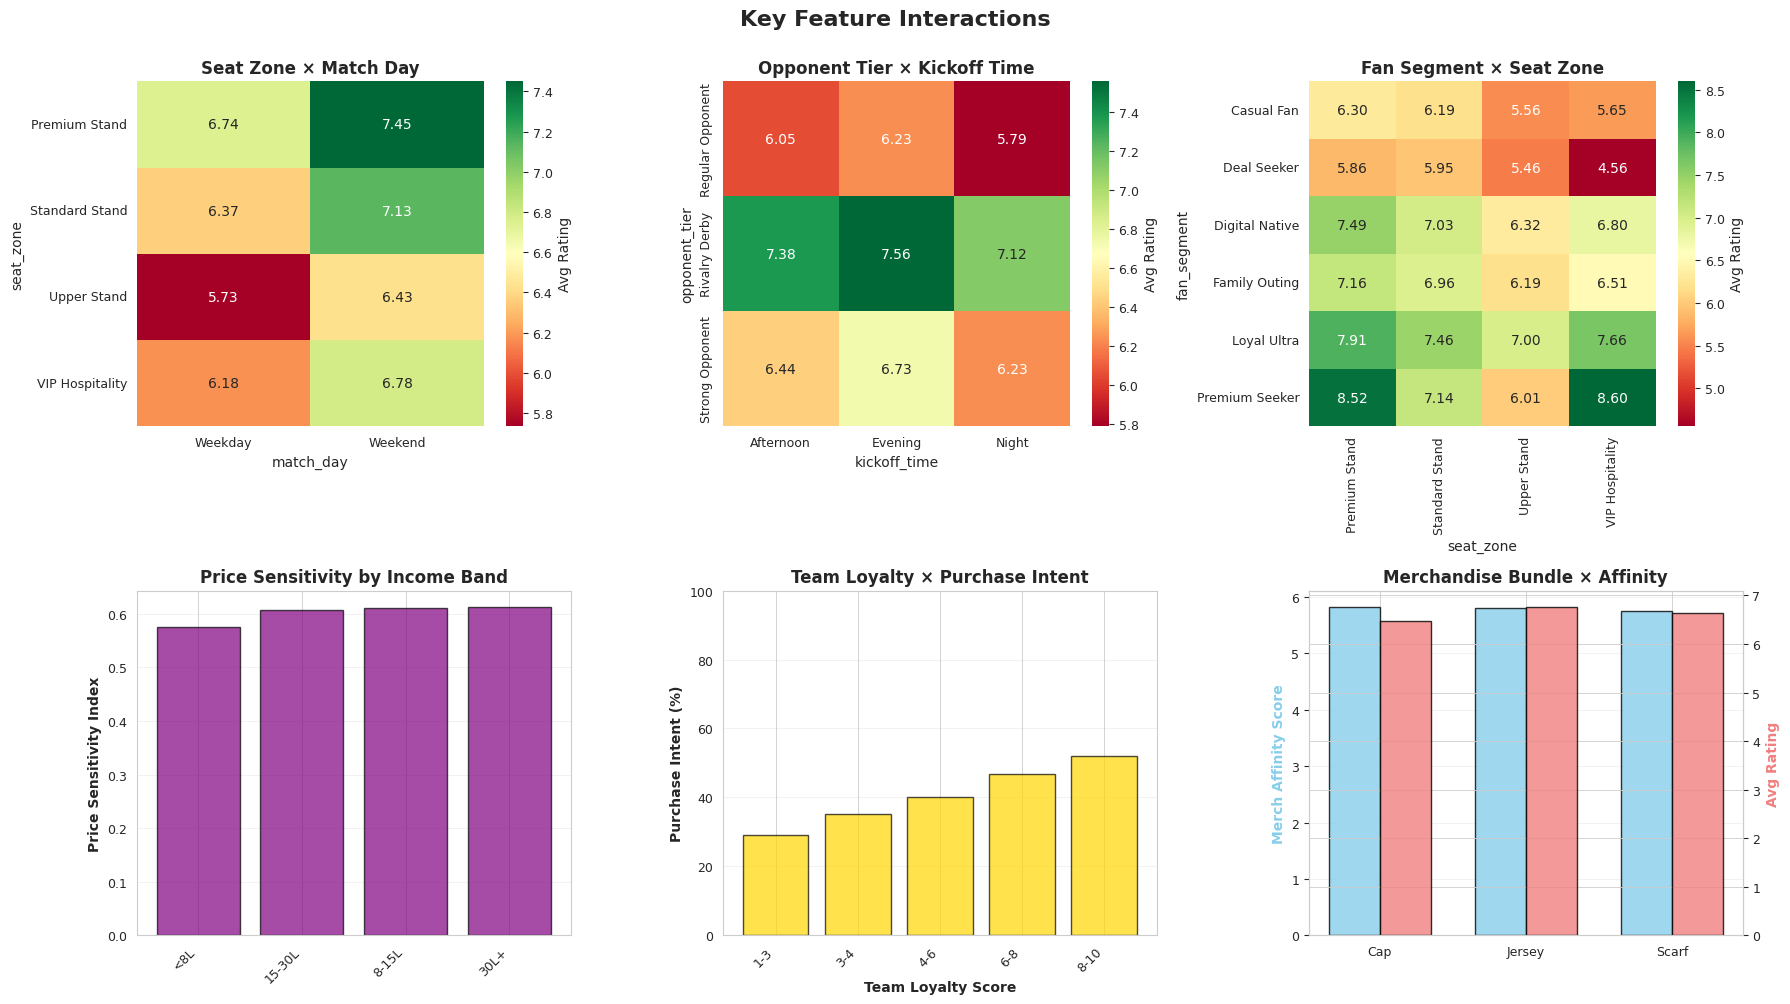

✓ Saved: 06_feature_interactions.png

EXPORTING RESULTS
✓ Saved: partworth_utilities_rating.csv
✓ Saved: partworth_utilities_purchase_intent.csv
✓ Saved: partworth_utilities_latent_utility.csv
✓ Saved: attribute_importance_rating.csv
✓ Saved: attribute_importance_purchase_intent.csv
✓ Saved: attribute_importance_latent_utility.csv
✓ Saved: price_analysis_summary.csv

ANALYSIS COMPLETE!

Generated Files:
  1. 01_model_performance.png - Model fit and residuals
  2. 02_attribute_importance.png - Attribute importance rankings
  3. 03_price_sensitivity.png - Price sensitivity analysis
  4. 04_partworth_utilities.png - Part-worth coefficients
  5. 05_segment_analysis.png - Customer segment analysis
  6. 06_feature_interactions.png - Feature interaction heatmaps
  + CSV files with detailed results


In [2]:
"""
Conjoint Analysis for Sports Ticket Pricing
============================================
Comprehensive analysis including attribute importance, utility estimation,
price sensitivity, segment analysis, and detailed visualizations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

def load_and_prepare_data(file_path):
    """Load data and perform initial preprocessing"""
    df = pd.read_csv(file_path)
    print("Dataset Shape:", df.shape)
    print("\n" + "="*80)
    print("DATASET OVERVIEW")
    print("="*80)
    print(df.head())
    print(f"\nTotal Respondents: {df['respondent_id'].nunique()}")
    print(f"Total Profiles per Respondent: {df.groupby('respondent_id').size().unique()}")

    return df

# ============================================================================
# 2. FEATURE ENGINEERING FOR CONJOINT ANALYSIS
# ============================================================================

def engineer_features(df):
    """Create dummy variables for categorical attributes and prepare for modeling"""
    df_encoded = df.copy()

    # Define categorical and continuous columns
    categorical_cols = [
        'seat_zone', 'opponent_tier', 'match_day', 'kickoff_time',
        'merch_bundle', 'food_voucher', 'parking_included', 'digital_collectible'
    ]

    continuous_cols = ['price_inr']

    # Create dummy variables for categorical features
    df_dummies = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=False)

    # Get the encoded column names
    encoded_cols = [col for col in df_dummies.columns if any(cat in col for cat in categorical_cols)]
    encoded_cols.append('price_inr')

    print("\n" + "="*80)
    print("FEATURE ENGINEERING")
    print("="*80)
    print(f"Categorical Features: {categorical_cols}")
    print(f"Continuous Features: {continuous_cols}")
    print(f"Total Encoded Features: {len(encoded_cols)}")

    return df_dummies, encoded_cols, categorical_cols

# ============================================================================
# 3. CONJOINT ANALYSIS - PART-WORTH UTILITIES
# ============================================================================

def calculate_partworth_utilities(df_dummies, encoded_cols):
    """
    Estimate part-worth utilities using OLS regression
    Y = Rating or Purchase Intent
    X = Feature dummies + price
    """
    print("\n" + "="*80)
    print("CONJOINT MODEL - PART-WORTH UTILITIES")
    print("="*80)

    # Target variables
    targets = {
        'rating': 'rating_1_10',
        'purchase_intent': 'purchase_intent_binary',
        'latent_utility': 'latent_utility_true_for_teaching'
    }

    results = {}

    for target_name, target_col in targets.items():
        print(f"\n--- {target_name.upper()} MODEL ---")

        # Prepare X and y
        X = df_dummies[encoded_cols]
        y = df_dummies[target_col]

        # Fit model
        model = LinearRegression()
        model.fit(X, y)

        # Get results
        r2 = model.score(X, y)

        # Create coefficients dataframe
        coef_df = pd.DataFrame({
            'Feature': encoded_cols,
            'Coefficient': model.coef_,
            'Abs_Coefficient': np.abs(model.coef_)
        }).sort_values('Abs_Coefficient', ascending=False)

        results[target_name] = {
            'model': model,
            'r2': r2,
            'intercept': model.intercept_,
            'coefficients': coef_df,
            'X': X,
            'y': y
        }

        print(f"R² Score: {r2:.4f}")
        print(f"Intercept: {model.intercept_:.4f}")
        print("\nTop 10 Important Features:")
        print(coef_df.head(10).to_string(index=False))

    return results

# ============================================================================
# 4. ATTRIBUTE IMPORTANCE CALCULATION
# ============================================================================

def calculate_attribute_importance(results, df_dummies, encoded_cols, categorical_cols):
    """
    Calculate attribute importance as the range of part-worths for each attribute
    Importance = Max utility - Min utility for each attribute
    """
    print("\n" + "="*80)
    print("ATTRIBUTE IMPORTANCE ANALYSIS")
    print("="*80)

    importance_results = {}

    for target_name, result in results.items():
        coef_df = result['coefficients'].copy()

        # Extract attribute from feature name
        def extract_attribute(feature):
            for cat in categorical_cols:
                if cat in feature:
                    return cat
            return 'price_inr'

        coef_df['Attribute'] = coef_df['Feature'].apply(extract_attribute)

        # Calculate importance per attribute
        importance = coef_df.groupby('Attribute')['Coefficient'].agg(['max', 'min'])
        importance['Importance'] = importance['max'] - importance['min']
        importance['Relative_Importance_%'] = (importance['Importance'] / importance['Importance'].sum()) * 100
        importance = importance.sort_values('Importance', ascending=False)

        importance_results[target_name] = importance

        print(f"\n{target_name.upper()} - Attribute Importance:")
        print(importance[['Importance', 'Relative_Importance_%']].to_string())

    return importance_results

# ============================================================================
# 5. PRICE SENSITIVITY & ELASTICITY ANALYSIS
# ============================================================================

def analyze_price_sensitivity(results, df, df_dummies):
    """
    Analyze price sensitivity and willingness-to-pay (WTP)
    """
    print("\n" + "="*80)
    print("PRICE SENSITIVITY & ELASTICITY ANALYSIS")
    print("="*80)

    price_analysis = {}

    for target_name, result in results.items():
        coef_df = result['coefficients']
        price_coef = coef_df[coef_df['Feature'] == 'price_inr']['Coefficient'].values[0]

        # Correlation between price and rating
        price_corr = df['price_inr'].corr(df[f'rating_1_10' if target_name == 'rating' else 'purchase_intent_binary'])

        # Average WTP vs Actual Price
        avg_actual_price = df['price_inr'].mean()
        avg_wtp = df['stated_wtp_inr'].mean()
        wtp_premium = ((avg_wtp - avg_actual_price) / avg_actual_price) * 100

        # Price sensitivity index
        price_sensitivity_mean = df['price_sensitivity_index'].mean()

        price_analysis[target_name] = {
            'price_coefficient': price_coef,
            'price_correlation': price_corr,
            'avg_actual_price': avg_actual_price,
            'avg_wtp': avg_wtp,
            'wtp_premium_%': wtp_premium,
            'price_sensitivity_mean': price_sensitivity_mean
        }

        print(f"\n{target_name.upper()}:")
        print(f"  Price Coefficient: {price_coef:.6f}")
        print(f"  Price-Rating Correlation: {price_corr:.4f}")
        print(f"  Average Actual Price: ₹{avg_actual_price:.2f}")
        print(f"  Average Stated WTP: ₹{avg_wtp:.2f}")
        print(f"  WTP Premium over Actual Price: {wtp_premium:.2f}%")
        print(f"  Mean Price Sensitivity Index: {price_sensitivity_mean:.4f}")

    return price_analysis

# ============================================================================
# 6. SEGMENT ANALYSIS
# ============================================================================

def segment_analysis(df):
    """
    Analyze preferences by customer segments
    """
    print("\n" + "="*80)
    print("SEGMENT ANALYSIS")
    print("="*80)

    # Segment by fan_segment
    print("\n1. BY FAN SEGMENT:")
    fan_segment_analysis = df.groupby('fan_segment').agg({
        'rating_1_10': 'mean',
        'purchase_intent_binary': lambda x: (x.sum() / len(x)) * 100,
        'price_inr': 'mean',
        'stated_wtp_inr': 'mean',
        'price_sensitivity_index': 'mean',
        'team_loyalty_score': 'mean'
    }).round(3)

    fan_segment_analysis.columns = ['Avg_Rating', 'Purchase_Intent_%', 'Avg_Price', 'Avg_WTP', 'Price_Sensitivity', 'Team_Loyalty']
    print(fan_segment_analysis)

    # Segment by income
    print("\n2. BY INCOME BAND:")
    income_analysis = df.groupby('income_band').agg({
        'rating_1_10': 'mean',
        'purchase_intent_binary': lambda x: (x.sum() / len(x)) * 100,
        'price_inr': 'mean',
        'stated_wtp_inr': 'mean'
    }).round(3)
    income_analysis.columns = ['Avg_Rating', 'Purchase_Intent_%', 'Avg_Price', 'Avg_WTP']
    print(income_analysis)

    # Segment by location
    print("\n3. BY CITY DISTANCE:")
    distance_analysis = df.groupby('city_distance_band').agg({
        'rating_1_10': 'mean',
        'purchase_intent_binary': lambda x: (x.sum() / len(x)) * 100,
        'travel_distance_km': 'mean',
        'price_inr': 'mean'
    }).round(3)
    distance_analysis.columns = ['Avg_Rating', 'Purchase_Intent_%', 'Avg_Travel_km', 'Avg_Price']
    print(distance_analysis)

    return fan_segment_analysis, income_analysis, distance_analysis

# ============================================================================
# 7. VISUALIZATION FUNCTIONS
# ============================================================================

def create_visualizations(df, results, importance_results, price_analysis,
                         fan_segment_analysis, income_analysis, distance_analysis):
    """
    Create comprehensive visualization dashboard
    """

    # Set style
    sns.set_style("whitegrid")
    plt.rcParams['figure.facecolor'] = 'white'

    # ========================================================================
    # FIGURE 1: Model Performance & Residuals
    # ========================================================================
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Conjoint Model Performance & Diagnostics', fontsize=16, fontweight='bold', y=1.00)

    for idx, (target_name, result) in enumerate(results.items()):
        # Model fit scatter
        y_pred = result['model'].predict(result['X'])
        y_actual = result['y']

        ax1 = axes[0, idx]
        ax1.scatter(y_actual, y_pred, alpha=0.5, s=20, color=f'C{idx}')
        ax1.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
        ax1.set_xlabel('Actual Values', fontweight='bold')
        ax1.set_ylabel('Predicted Values', fontweight='bold')
        ax1.set_title(f'{target_name.capitalize()} - Fit (R²={result["r2"]:.4f})', fontweight='bold')
        ax1.grid(True, alpha=0.3)

        # Residuals distribution
        residuals = y_actual - y_pred
        ax2 = axes[1, idx]
        ax2.hist(residuals, bins=30, alpha=0.7, color=f'C{idx}', edgecolor='black')
        ax2.axvline(residuals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={residuals.mean():.3f}')
        ax2.set_xlabel('Residuals', fontweight='bold')
        ax2.set_ylabel('Frequency', fontweight='bold')
        ax2.set_title(f'{target_name.capitalize()} - Residual Distribution', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('01_model_performance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 01_model_performance.png")

    # ========================================================================
    # FIGURE 2: Attribute Importance Rankings
    # ========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Attribute Importance Analysis', fontsize=16, fontweight='bold', y=1.02)

    colors_palette = sns.color_palette("husl", 8)

    for idx, (target_name, importance) in enumerate(importance_results.items()):
        ax = axes[idx]
        importance_sorted = importance.sort_values('Relative_Importance_%', ascending=True)

        bars = ax.barh(range(len(importance_sorted)), importance_sorted['Relative_Importance_%'], color=colors_palette)
        ax.set_yticks(range(len(importance_sorted)))
        ax.set_yticklabels(importance_sorted.index, fontweight='bold')
        ax.set_xlabel('Relative Importance (%)', fontweight='bold')
        ax.set_title(f'{target_name.capitalize()}', fontweight='bold', fontsize=12)
        ax.grid(True, alpha=0.3, axis='x')

        # Add value labels
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2,
                   f'{width:.1f}%', ha='left', va='center', fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.savefig('02_attribute_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 02_attribute_importance.png")

    # ========================================================================
    # FIGURE 3: Price Sensitivity Analysis
    # ========================================================================
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Price Sensitivity & WTP Analysis', fontsize=16, fontweight='bold', y=1.00)

    # Price vs Rating by Fan Segment
    ax = axes[0, 0]
    for segment in df['fan_segment'].unique():
        segment_data = df[df['fan_segment'] == segment]
        ax.scatter(segment_data['price_inr'], segment_data['rating_1_10'],
                  alpha=0.6, label=segment, s=30)
    ax.set_xlabel('Price (₹)', fontweight='bold')
    ax.set_ylabel('Rating (1-10)', fontweight='bold')
    ax.set_title('Price vs Rating by Fan Segment', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Price vs Purchase Intent
    ax = axes[0, 1]
    price_bins = pd.cut(df['price_inr'], bins=5)
    purchase_by_price = df.groupby(price_bins)['purchase_intent_binary'].agg(['mean', 'count'])
    x_pos = range(len(purchase_by_price))
    bars = ax.bar(x_pos, purchase_by_price['mean']*100, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'₹{int(interval.left)}-{int(interval.right)}' for interval in purchase_by_price.index],
                       rotation=45, ha='right')
    ax.set_ylabel('Purchase Intent (%)', fontweight='bold')
    ax.set_title('Purchase Intent by Price Range', fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y')

    # WTP vs Actual Price
    ax = axes[0, 2]
    wtp_comparison = df.groupby('fan_segment').agg({'price_inr': 'mean', 'stated_wtp_inr': 'mean'})
    x = np.arange(len(wtp_comparison))
    width = 0.35
    ax.bar(x - width/2, wtp_comparison['price_inr'], width, label='Actual Price', alpha=0.8, color='coral')
    ax.bar(x + width/2, wtp_comparison['stated_wtp_inr'], width, label='Stated WTP', alpha=0.8, color='steelblue')
    ax.set_xticks(x)
    ax.set_xticklabels(wtp_comparison.index, rotation=45, ha='right')
    ax.set_ylabel('Price (₹)', fontweight='bold')
    ax.set_title('WTP vs Actual Price by Segment', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Price sensitivity distribution
    ax = axes[1, 0]
    ax.hist(df['price_sensitivity_index'], bins=30, alpha=0.7, color='green', edgecolor='black')
    ax.axvline(df['price_sensitivity_index'].mean(), color='red', linestyle='--', linewidth=2,
              label=f'Mean={df["price_sensitivity_index"].mean():.3f}')
    ax.set_xlabel('Price Sensitivity Index', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title('Distribution of Price Sensitivity', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Seat Zone Price Premium
    ax = axes[1, 1]
    seat_price = df.groupby('seat_zone').agg({'price_inr': 'mean', 'rating_1_10': 'mean'})
    seat_price = seat_price.sort_values('price_inr', ascending=False)
    bars = ax.bar(range(len(seat_price)), seat_price['price_inr'], color='teal', alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(seat_price)))
    ax.set_xticklabels(seat_price.index, rotation=45, ha='right')
    ax.set_ylabel('Average Price (₹)', fontweight='bold')
    ax.set_title('Average Price by Seat Zone', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Opponent Tier Impact on Price & Rating
    ax = axes[1, 2]
    opponent_analysis = df.groupby('opponent_tier').agg({'price_inr': 'mean', 'rating_1_10': 'mean'})
    ax2 = ax.twinx()

    bars = ax.bar(range(len(opponent_analysis)), opponent_analysis['price_inr'],
                  alpha=0.7, color='lightcoral', label='Avg Price', edgecolor='black')
    line = ax2.plot(range(len(opponent_analysis)), opponent_analysis['rating_1_10'],
                    'o-', color='darkblue', linewidth=2, markersize=8, label='Avg Rating')

    ax.set_xticks(range(len(opponent_analysis)))
    ax.set_xticklabels(opponent_analysis.index, rotation=45, ha='right')
    ax.set_ylabel('Average Price (₹)', fontweight='bold', color='lightcoral')
    ax2.set_ylabel('Average Rating', fontweight='bold', color='darkblue')
    ax.set_title('Price & Rating by Opponent Tier', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('03_price_sensitivity.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 03_price_sensitivity.png")

    # ========================================================================
    # FIGURE 4: Part-Worth Utilities
    # ========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Part-Worth Utilities by Feature', fontsize=16, fontweight='bold', y=1.02)

    for idx, (target_name, result) in enumerate(results.items()):
        ax = axes[idx]
        coef_df = result['coefficients'].head(15).sort_values('Coefficient')

        colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
        bars = ax.barh(range(len(coef_df)), coef_df['Coefficient'], color=colors, alpha=0.7, edgecolor='black')

        ax.set_yticks(range(len(coef_df)))
        ax.set_yticklabels(coef_df['Feature'], fontsize=9, fontweight='bold')
        ax.set_xlabel('Coefficient Value', fontweight='bold')
        ax.set_title(f'{target_name.capitalize()} - Top 15 Features', fontweight='bold')
        ax.axvline(0, color='black', linestyle='-', linewidth=1)
        ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('04_partworth_utilities.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 04_partworth_utilities.png")

    # ========================================================================
    # FIGURE 5: Segment Analysis
    # ========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Customer Segment Analysis', fontsize=16, fontweight='bold', y=0.995)

    # Fan Segment Analysis
    ax = axes[0, 0]
    fan_segment_analysis.sort_values('Avg_Rating').plot(y=['Avg_Rating', 'Purchase_Intent_%'],
                                                        ax=ax, kind='barh', color=['steelblue', 'coral'], alpha=0.8)
    ax.set_xlabel('Value', fontweight='bold')
    ax.set_title('Fan Segment: Rating & Purchase Intent', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    ax.legend(['Avg Rating', 'Purchase Intent %'], loc='lower right')

    # Income Band Analysis
    ax = axes[0, 1]
    income_sorted = income_analysis.sort_values('Avg_Price')
    income_sorted[['Avg_Rating', 'Avg_WTP']].plot(ax=ax, marker='o', linewidth=2, markersize=8)
    ax.set_xlabel('Income Band', fontweight='bold')
    ax.set_ylabel('Value', fontweight='bold')
    ax.set_title('Income Band: Rating & WTP Trend', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(['Avg Rating', 'Avg WTP'], loc='upper left')

    # Distance Band Analysis
    ax = axes[1, 0]
    distance_analysis.plot(y=['Avg_Rating', 'Purchase_Intent_%'], ax=ax, marker='s', linewidth=2, markersize=8)
    ax.set_xlabel('City Distance', fontweight='bold')
    ax.set_ylabel('Value', fontweight='bold')
    ax.set_title('Distance Band: Rating & Purchase Intent', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(['Avg Rating', 'Purchase Intent %'], loc='best')

    # Bundle & Add-on Impact
    ax = axes[1, 1]
    addons = ['merch_bundle', 'food_voucher', 'parking_included', 'digital_collectible']
    addon_impact = []
    for addon in addons:
        with_addon = df[df[addon] == 'Yes']['rating_1_10'].mean()
        without_addon = df[df[addon] == 'No']['rating_1_10'].mean()
        addon_impact.append(with_addon - without_addon)

    colors_addon = ['green' if x > 0 else 'red' for x in addon_impact]
    bars = ax.bar(addons, addon_impact, color=colors_addon, alpha=0.7, edgecolor='black')
    ax.set_ylabel('Rating Impact', fontweight='bold')
    ax.set_title('Add-on Impact on Rating', fontweight='bold')
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.set_xticklabels(addons, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, addon_impact)):
        ax.text(i, val, f'{val:.2f}', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')

    plt.tight_layout()
    plt.savefig('05_segment_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 05_segment_analysis.png")

    # ========================================================================
    # FIGURE 6: Feature Interaction Analysis
    # ========================================================================
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Key Feature Interactions', fontsize=16, fontweight='bold', y=1.00)

    # Seat Zone vs Match Day
    ax = axes[0, 0]
    seat_match = df.pivot_table(values='rating_1_10', index='seat_zone', columns='match_day', aggfunc='mean')
    sns.heatmap(seat_match, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Avg Rating'})
    ax.set_title('Seat Zone × Match Day', fontweight='bold')

    # Opponent Tier vs Kickoff Time
    ax = axes[0, 1]
    opponent_time = df.pivot_table(values='rating_1_10', index='opponent_tier', columns='kickoff_time', aggfunc='mean')
    sns.heatmap(opponent_time, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Avg Rating'})
    ax.set_title('Opponent Tier × Kickoff Time', fontweight='bold')

    # Fan Segment vs Seat Zone
    ax = axes[0, 2]
    fan_seat = df.pivot_table(values='rating_1_10', index='fan_segment', columns='seat_zone', aggfunc='mean')
    sns.heatmap(fan_seat, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Avg Rating'})
    ax.set_title('Fan Segment × Seat Zone', fontweight='bold')

    # Price Sensitivity × Income
    ax = axes[1, 0]
    price_sens_income = df.pivot_table(values='price_sensitivity_index', index='income_band',
                                       columns='price_inr', aggfunc='mean')
    income_price_sens = df.groupby('income_band')['price_sensitivity_index'].mean().sort_values()
    bars = ax.bar(range(len(income_price_sens)), income_price_sens.values, alpha=0.7, color='purple', edgecolor='black')
    ax.set_xticks(range(len(income_price_sens)))
    ax.set_xticklabels(income_price_sens.index, rotation=45, ha='right')
    ax.set_ylabel('Price Sensitivity Index', fontweight='bold')
    ax.set_title('Price Sensitivity by Income Band', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Team Loyalty vs Purchase Intent
    ax = axes[1, 1]
    loyalty_bins = pd.cut(df['team_loyalty_score'], bins=5)
    loyalty_purchase = df.groupby(loyalty_bins)['purchase_intent_binary'].agg(['mean', 'count'])
    x_pos = range(len(loyalty_purchase))
    bars = ax.bar(x_pos, loyalty_purchase['mean']*100, color='gold', alpha=0.7, edgecolor='black')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'{int(interval.left)}-{int(interval.right)}' for interval in loyalty_purchase.index], rotation=45, ha='right')
    ax.set_ylabel('Purchase Intent (%)', fontweight='bold')
    ax.set_xlabel('Team Loyalty Score', fontweight='bold')
    ax.set_title('Team Loyalty × Purchase Intent', fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y')

    # Merchandise Affinity × Merchandise Bundle
    ax = axes[1, 2]
    merch_impact = df.groupby(['merch_bundle']).agg({'merchandise_affinity_score': 'mean', 'rating_1_10': 'mean'})
    x = np.arange(len(merch_impact))
    width = 0.35
    ax2 = ax.twinx()
    bars1 = ax.bar(x - width/2, merch_impact['merchandise_affinity_score'], width, label='Merch Affinity',
                   alpha=0.8, color='skyblue', edgecolor='black')
    bars2 = ax2.bar(x + width/2, merch_impact['rating_1_10'], width, label='Avg Rating',
                    alpha=0.8, color='lightcoral', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(merch_impact.index)
    ax.set_ylabel('Merch Affinity Score', fontweight='bold', color='skyblue')
    ax2.set_ylabel('Avg Rating', fontweight='bold', color='lightcoral')
    ax.set_title('Merchandise Bundle × Affinity', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('06_feature_interactions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 06_feature_interactions.png")

# ============================================================================
# 8. EXPORT RESULTS
# ============================================================================

def export_results(results, importance_results, price_analysis, df):
    """Export key results to CSV files"""

    print("\n" + "="*80)
    print("EXPORTING RESULTS")
    print("="*80)

    # Part-worth utilities
    for target_name, result in results.items():
        coef_df = result['coefficients'].copy()
        coef_df.to_csv(f'partworth_utilities_{target_name}.csv', index=False)
        print(f"✓ Saved: partworth_utilities_{target_name}.csv")

    # Attribute importance
    for target_name, importance in importance_results.items():
        importance.to_csv(f'attribute_importance_{target_name}.csv')
        print(f"✓ Saved: attribute_importance_{target_name}.csv")

    # Price analysis summary
    price_summary = pd.DataFrame(price_analysis).T
    price_summary.to_csv('price_analysis_summary.csv')
    print(f"✓ Saved: price_analysis_summary.csv")

# ============================================================================
# 9. MAIN EXECUTION
# ============================================================================

def main():
    print("\n" + "="*80)
    print("CONJOINT ANALYSIS FOR SPORTS TICKET PRICING")
    print("="*80)

    # Load data
    df = load_and_prepare_data('/content/dataset_1_sports_ticket_conjoint.csv')

    # Feature engineering
    df_dummies, encoded_cols, categorical_cols = engineer_features(df)

    # Conjoint analysis
    results = calculate_partworth_utilities(df_dummies, encoded_cols)

    # Attribute importance
    importance_results = calculate_attribute_importance(results, df_dummies, encoded_cols, categorical_cols)

    # Price sensitivity
    price_analysis = analyze_price_sensitivity(results, df, df_dummies)

    # Segment analysis
    fan_segment_analysis, income_analysis, distance_analysis = segment_analysis(df)

    # Create visualizations
    create_visualizations(df, results, importance_results, price_analysis,
                         fan_segment_analysis, income_analysis, distance_analysis)

    # Export results
    export_results(results, importance_results, price_analysis, df)

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)
    print("\nGenerated Files:")
    print("  1. 01_model_performance.png - Model fit and residuals")
    print("  2. 02_attribute_importance.png - Attribute importance rankings")
    print("  3. 03_price_sensitivity.png - Price sensitivity analysis")
    print("  4. 04_partworth_utilities.png - Part-worth coefficients")
    print("  5. 05_segment_analysis.png - Customer segment analysis")
    print("  6. 06_feature_interactions.png - Feature interaction heatmaps")
    print("  + CSV files with detailed results")

if __name__ == "__main__":
    main()

Raw shape: (14880, 28)
Unique respondents: 620
Profiles per respondent (mean, sd): 24.0, 0.0

Attribute levels:
  seat_zone              (4 levels): ['Premium Stand', 'Standard Stand', 'Upper Stand', 'VIP Hospitality']
  opponent_tier          (3 levels): ['Regular Opponent', 'Rivalry Derby', 'Strong Opponent']
  match_day              (2 levels): ['Weekday', 'Weekend']
  kickoff_time           (3 levels): ['Afternoon', 'Evening', 'Night']
  merch_bundle           (3 levels): ['Cap', 'Jersey', 'Scarf']
  food_voucher           (2 levels): ['No', 'Yes']
  parking_included       (2 levels): ['No', 'Yes']
  digital_collectible    (2 levels): ['No', 'Yes']

Train rows: 7662 | Test rows: 1801

Design matrix: 15 columns (1 intercept + 1 price + 13 effects codes)

  OLS CONJOINT MODEL — Cluster-robust SEs on respondent_id
  R² (train)        : 0.2418
  Adj. R² (train)   : 0.2404
  F-stat            : 163.52   (p = 8.34e-181)
  N obs / clusters  : 7662 / 525

----------------------------------

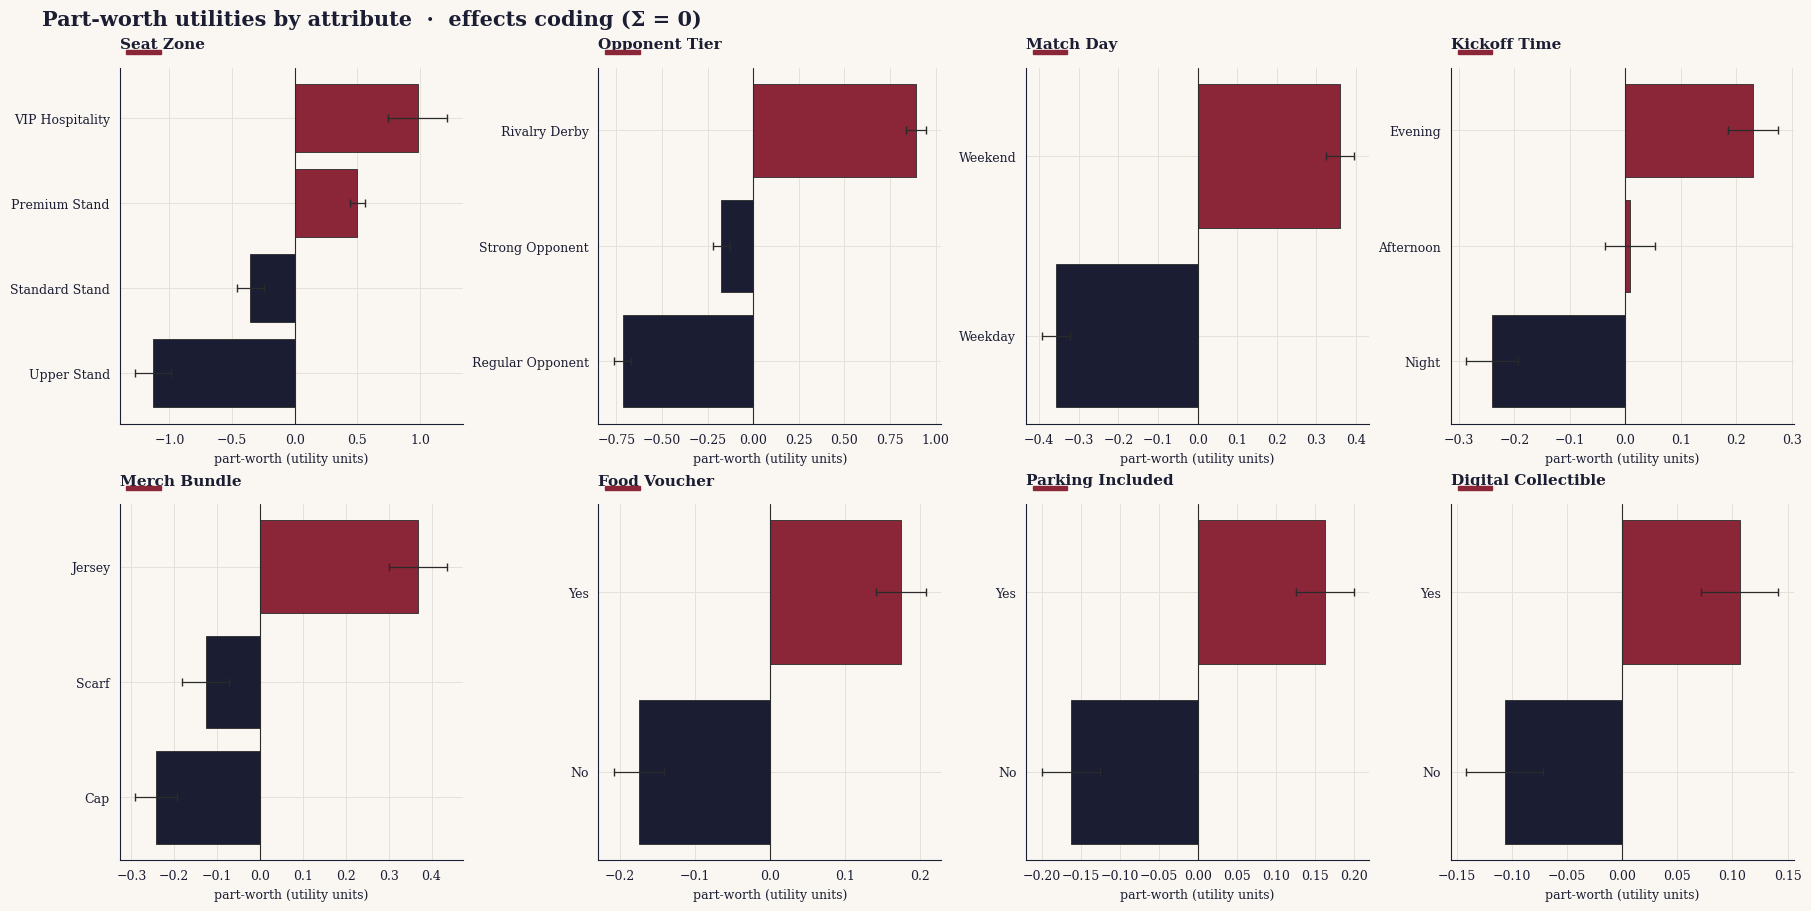

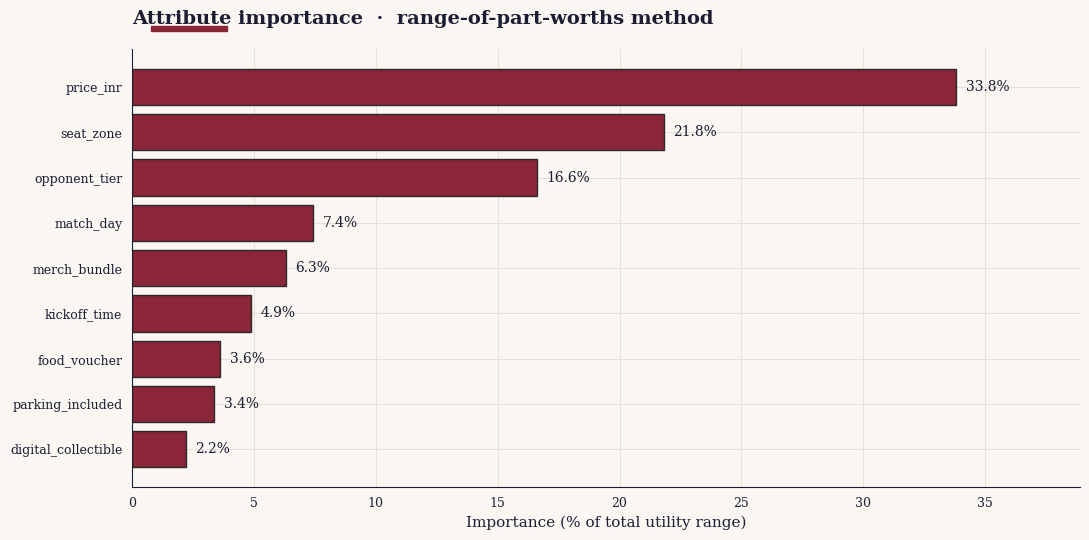

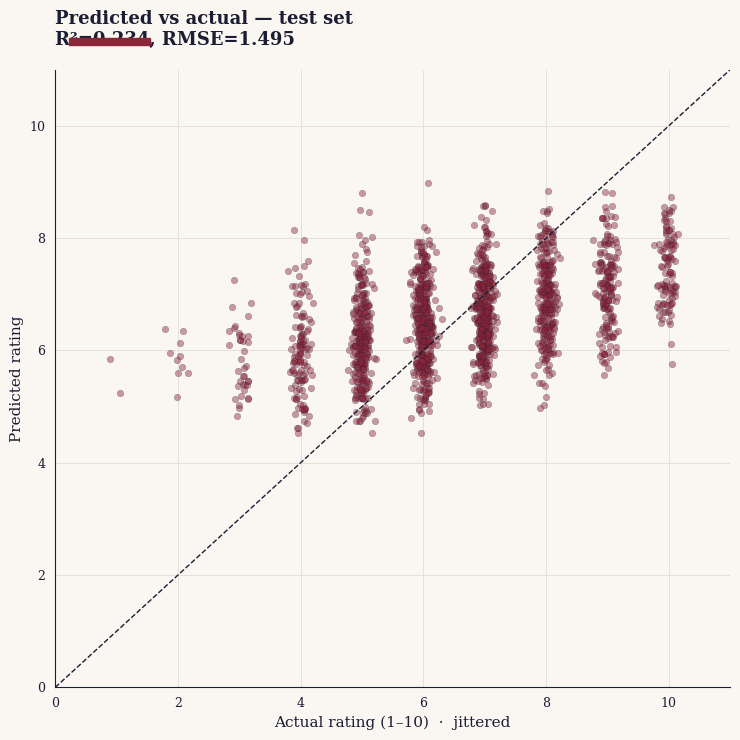

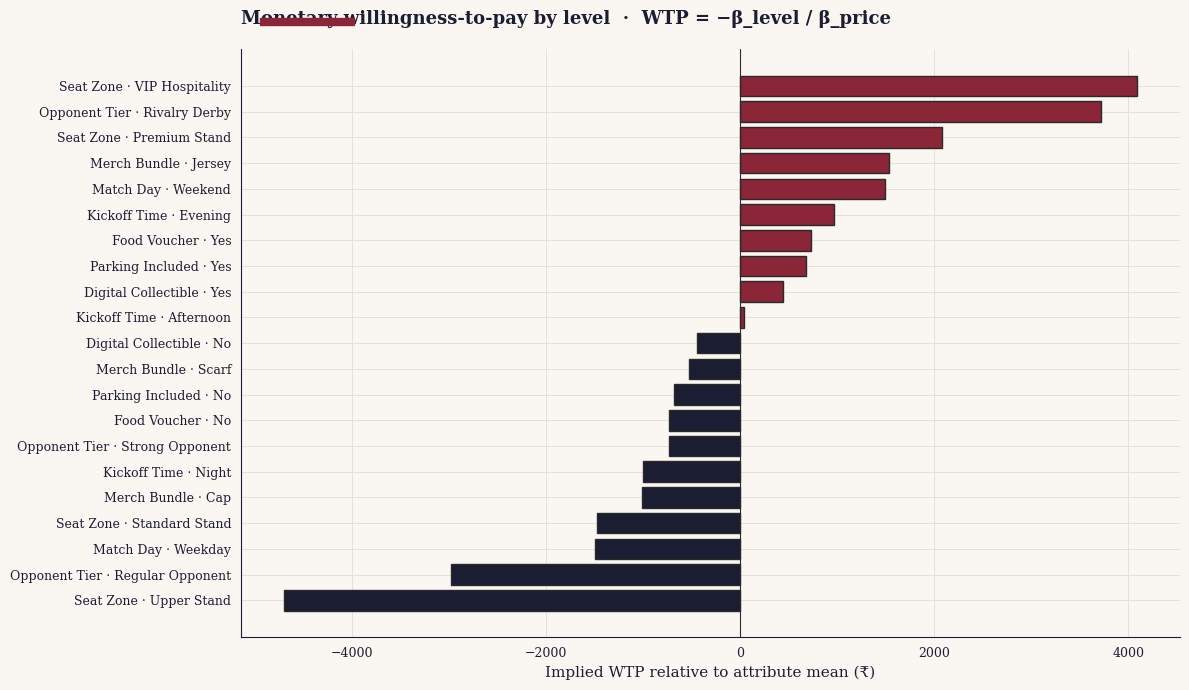

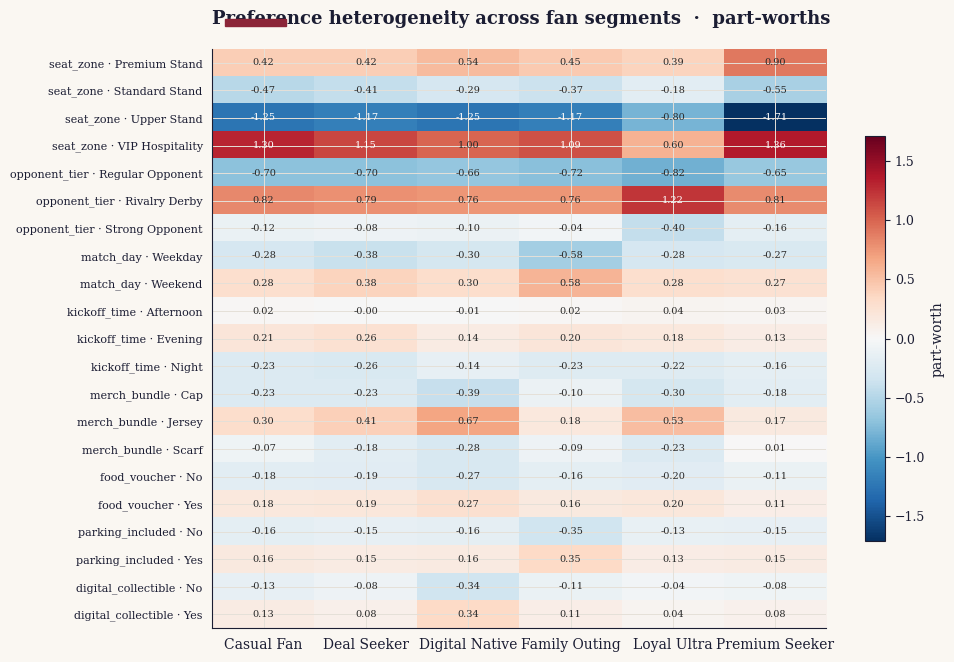

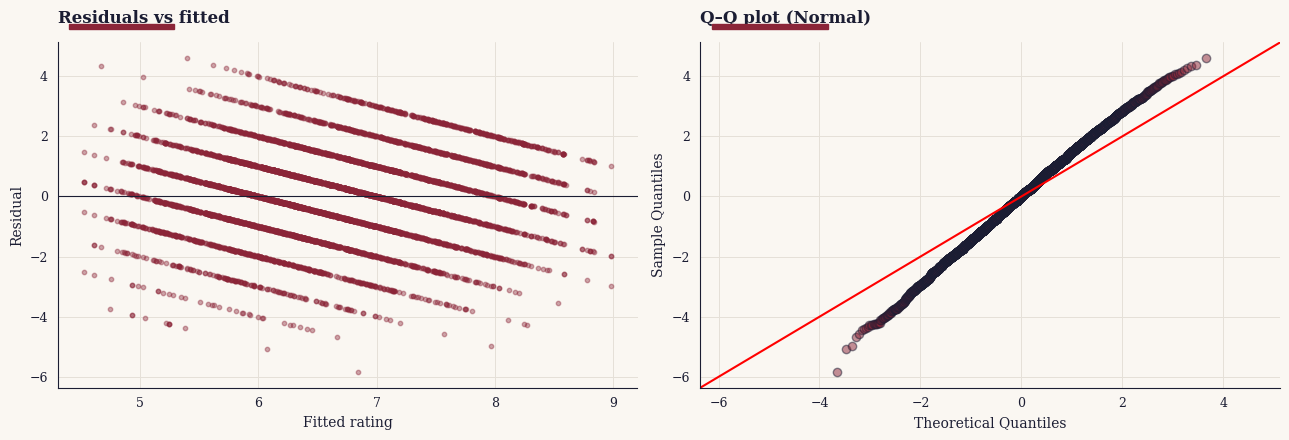


██████████████████████████████████████████████████████████████████████████████
  CLASSROOM DISCUSSION PROMPTS
██████████████████████████████████████████████████████████████████████████████

  1. Why effects coding rather than dummy coding for conjoint reporting?
     What changes about interpretation if we switched to dummy coding?
  2. The Pearson correlation of fitted ratings with the latent utility is
     a teaching aid — in real-world conjoint, this validation column does
     NOT exist.  What would you substitute?  (Hint: holdout choice tasks,
     hit rates, share-of-preference.)
  3. We treated 1–10 ratings as metric.  When is that defensible?  Compare
     OLS β-signs with the ordinal logit β-signs printed above.
  4. The pooled model imposes preference homogeneity.  Look at the segment
     heatmap: which attributes show the most segment-by-attribute variation?
     What does that imply for targeting?
  5. WTP magnitudes here are *relative to the attribute mean*, not relativ

In [4]:
# =============================================================================
#  RATINGS-BASED CONJOINT ANALYSIS — Sports Ticket Profiles
#  Single-cell Google Colab script.  Designed for Session 1 of MRM teaching.
#
#  Method:        Metric (full-profile) conjoint via OLS with effects (sum-to-zero)
#                 coding; cluster-robust SEs on respondent_id; price entered
#                 linearly to permit monetary WTP recovery.
#  Key refs.:     Green & Srinivasan (1990, JMR); Rao (2014, Applied Conjoint
#                 Analysis); Orme (2010, Getting Started with Conjoint);
#                 Cameron & Miller (2015, JHR) for cluster-robust inference.
#  Caveats:       (i) Pooled OLS assumes homogeneous preferences — see segment
#                 panel for heterogeneity diagnostic; HB/mixed-logit is the
#                 production-grade extension.  (ii) Ratings are treated as
#                 metric — ordinal logit included as robustness.  (iii) Linear
#                 price assumes constant marginal disutility; log-price fit
#                 included as robustness.
# =============================================================================

# ---- 0. Imports -------------------------------------------------------------
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats import spearmanr, pearsonr
warnings.filterwarnings("ignore")

# ---- Aesthetic tokens (matching the course deck) ---------------------------
BERRY, NAVY, CREAM, INK = "#8B2538", "#1B1D33", "#FAF7F2", "#2A2A2A"
GREY, GOLD             = "#9A9A9A", "#C8A24B"
mpl.rcParams.update({
    "figure.facecolor": CREAM, "axes.facecolor": CREAM,
    "axes.edgecolor": NAVY,    "axes.labelcolor": NAVY,
    "xtick.color": NAVY,       "ytick.color": NAVY,
    "axes.titlecolor": NAVY,
    "font.family": "DejaVu Serif",   # Georgia substitute in Colab
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E5E0D8", "grid.linewidth": 0.7,
})

# ---- 1. Load ---------------------------------------------------------------
PATH = "/content/dataset_1_sports_ticket_conjoint.csv"
df   = pd.read_csv(PATH)
print(f"Raw shape: {df.shape}")
print(f"Unique respondents: {df['respondent_id'].nunique()}")
print(f"Profiles per respondent (mean, sd): "
      f"{df.groupby('respondent_id').size().mean():.1f}, "
      f"{df.groupby('respondent_id').size().std():.1f}")

# ---- 2. Clean & split ------------------------------------------------------
# Per data integrity convention: drop only flagged responses; missing values
# in respondent covariates are retained because they do not enter the design.
df = df[df["response_quality_flag"] == "Clean"].copy()
df = df.dropna(subset=["rating_1_10", "price_inr", "seat_zone", "opponent_tier",
                       "match_day", "kickoff_time", "merch_bundle",
                       "food_voucher", "parking_included", "digital_collectible"])

ATTRS  = ["seat_zone", "opponent_tier", "match_day", "kickoff_time",
          "merch_bundle", "food_voucher", "parking_included", "digital_collectible"]
LEVELS = {a: sorted(df[a].unique().tolist()) for a in ATTRS}
print("\nAttribute levels:")
for a, ls in LEVELS.items():
    print(f"  {a:<22s} ({len(ls)} levels): {ls}")

train = df[df["train_test_split"] == "train"].copy()
test  = df[df["train_test_split"] == "test"].copy()
print(f"\nTrain rows: {len(train)} | Test rows: {len(test)}")

# ---- 3. Effects (sum-to-zero) coding --------------------------------------
# Why effects coding rather than dummy coding?  In conjoint, the convention
# is to report part-worths as DEVIATIONS from the attribute mean (centred at
# zero) so that level utilities sum to zero within each attribute and remain
# directly comparable across attributes.  The omitted ("reference") level's
# part-worth is recovered as the negative sum of the estimated levels.
def effects_code(series: pd.Series, levels: list, base: str) -> pd.DataFrame:
    """Return effects-coded indicators with `base` as the reference level."""
    out = {}
    non_base = [l for l in levels if l != base]
    for lv in non_base:
        col = (series == lv).astype(int) - (series == base).astype(int)
        out[f"{series.name}__{lv}"] = col
    return pd.DataFrame(out, index=series.index)

# Reference level = first level alphabetically (arbitrary; symmetry holds).
BASES = {a: LEVELS[a][0] for a in ATTRS}

def build_X(frame: pd.DataFrame) -> pd.DataFrame:
    """Construct the conjoint design matrix: intercept + price + effects codes."""
    parts = [pd.DataFrame({"price_inr": frame["price_inr"].astype(float)},
                          index=frame.index)]
    for a in ATTRS:
        parts.append(effects_code(frame[a], LEVELS[a], BASES[a]))
    X = pd.concat(parts, axis=1)
    X = sm.add_constant(X, has_constant="add")
    return X

X_train, y_train = build_X(train), train["rating_1_10"].astype(float)
X_test,  y_test  = build_X(test),  test["rating_1_10"].astype(float)
print(f"\nDesign matrix: {X_train.shape[1]} columns "
      f"(1 intercept + 1 price + {X_train.shape[1]-2} effects codes)")

# ---- 4. Fit OLS with cluster-robust SEs -----------------------------------
# Within-respondent correlation across the ~19 profiles each respondent rates
# violates OLS iid assumption.  Cluster-robust (CR1) SEs on respondent_id
# correct inference (Cameron & Miller 2015).  Point estimates are unchanged;
# only SEs / p-values shift.
clusters = train["respondent_id"].values
model    = sm.OLS(y_train, X_train).fit(cov_type="cluster",
                                        cov_kwds={"groups": clusters})
print("\n" + "="*78)
print("  OLS CONJOINT MODEL — Cluster-robust SEs on respondent_id")
print("="*78)
print(f"  R² (train)        : {model.rsquared:.4f}")
print(f"  Adj. R² (train)   : {model.rsquared_adj:.4f}")
print(f"  F-stat            : {model.fvalue:.2f}   (p = {model.f_pvalue:.2e})")
print(f"  N obs / clusters  : {int(model.nobs)} / {len(np.unique(clusters))}")

# ---- 5. Recover full part-worth table (including reference levels) --------
def part_worth_table(model_fit) -> pd.DataFrame:
    rows = []
    coefs, ses, pv = model_fit.params, model_fit.bse, model_fit.pvalues
    for a in ATTRS:
        base = BASES[a]
        # Estimated levels (effects-coded)
        est_levels, est_pw, est_se, est_p = [], [], [], []
        for lv in LEVELS[a]:
            if lv == base: continue
            k = f"{a}__{lv}"
            est_levels.append(lv); est_pw.append(coefs[k])
            est_se.append(ses[k]); est_p.append(pv[k])
        # Reference level: pw_base = -sum(other pws); SE via linear combination
        pw_base = -np.sum(est_pw)
        # Var(-sum) = sum Var + 2*sum Cov  (full vcov for the attribute block)
        cols = [f"{a}__{lv}" for lv in est_levels]
        V = model_fit.cov_params().loc[cols, cols].values
        se_base = float(np.sqrt(np.ones(len(cols)) @ V @ np.ones(len(cols))))
        rows.append({"attribute": a, "level": base, "part_worth": pw_base,
                     "se": se_base, "p_value": np.nan, "is_reference": True})
        for lv, pw, se, p in zip(est_levels, est_pw, est_se, est_p):
            rows.append({"attribute": a, "level": lv, "part_worth": pw,
                         "se": se, "p_value": p, "is_reference": False})
    return pd.DataFrame(rows)

pw_df = part_worth_table(model)
print("\n" + "-"*78)
print("  PART-WORTHS (utility deviations from attribute mean)")
print("-"*78)
print(pw_df.to_string(index=False, float_format=lambda v: f"{v: .4f}"))

# ---- 6. Attribute importance ----------------------------------------------
# Standard CVA/CBC importance = range of part-worths within attribute, divided
# by the total range across all attributes (Orme 2010).  This is the
# conventional reporting metric; coefficient magnitudes alone are NOT
# importances.
ranges = pw_df.groupby("attribute")["part_worth"].agg(lambda s: s.max() - s.min())
# Price importance: convert price range (max-min observed) × |β_price|
price_range = (train["price_inr"].max() - train["price_inr"].min()) * abs(model.params["price_inr"])
ranges["price_inr"] = price_range
importance = (ranges / ranges.sum() * 100).sort_values(ascending=False)
print("\n" + "-"*78)
print("  ATTRIBUTE IMPORTANCE (% of total utility range)")
print("-"*78)
print(importance.round(2).to_string())

# ---- 7. Monetary WTP per level --------------------------------------------
# WTP_level = -part_worth(level) / β_price  (rupees a respondent would pay to
# obtain that level relative to the attribute mean).  Sign convention: a
# positive WTP means the level is preferred above the attribute average.
beta_p = model.params["price_inr"]
pw_df["wtp_inr"] = -pw_df["part_worth"] / beta_p
print("\n" + "-"*78)
print(f"  IMPLIED WTP PER LEVEL   (β_price = {beta_p:.6f} per ₹)")
print("-"*78)
print(pw_df[["attribute","level","part_worth","wtp_inr"]]
        .to_string(index=False, float_format=lambda v: f"{v: .2f}"))

# ---- 8. Out-of-sample validation -----------------------------------------
yhat_tr = model.predict(X_train)
yhat_te = model.predict(X_test)
def metrics(y, yhat):
    e = y - yhat
    return dict(R2=1 - (e**2).sum()/((y-y.mean())**2).sum(),
                RMSE=float(np.sqrt((e**2).mean())),
                MAE=float(np.abs(e).mean()))
m_tr, m_te = metrics(y_train, yhat_tr), metrics(y_test, yhat_te)
# Correlation with the teaching-truth latent utility (held-out construct check)
rho_tr_p, _  = pearsonr(yhat_tr, train["latent_utility_true_for_teaching"])
rho_te_p, _  = pearsonr(yhat_te, test["latent_utility_true_for_teaching"])
rho_te_s, _  = spearmanr(yhat_te, test["latent_utility_true_for_teaching"])
print("\n" + "="*78)
print("  VALIDATION")
print("="*78)
print(f"  Train   : R²={m_tr['R2']:.4f}  RMSE={m_tr['RMSE']:.3f}  MAE={m_tr['MAE']:.3f}")
print(f"  Test    : R²={m_te['R2']:.4f}  RMSE={m_te['RMSE']:.3f}  MAE={m_te['MAE']:.3f}")
print(f"  Pred ↔ latent utility (Pearson, train): {rho_tr_p: .3f}")
print(f"  Pred ↔ latent utility (Pearson, test) : {rho_te_p: .3f}")
print(f"  Pred ↔ latent utility (Spearman, test): {rho_te_s: .3f}")
print("  Interpretation: a small train→test gap and high construct correlation "
      "support external validity of the part-worth structure.")

# ---- 9. Segment heterogeneity (poor-man's HB) ----------------------------
seg_pw = {}
for seg, sub in train.groupby("fan_segment"):
    if len(sub) < 50: continue
    Xs, ys = build_X(sub), sub["rating_1_10"].astype(float)
    fit = sm.OLS(ys, Xs).fit(cov_type="cluster",
                             cov_kwds={"groups": sub["respondent_id"].values})
    rows = []
    for a in ATTRS:
        base = BASES[a]
        ests = [fit.params.get(f"{a}__{lv}", 0.0) for lv in LEVELS[a] if lv != base]
        pwb  = -sum(ests)
        rows.append({"attribute": a, "level": base, "part_worth": pwb})
        for lv, e in zip([l for l in LEVELS[a] if l != base], ests):
            rows.append({"attribute": a, "level": lv, "part_worth": e})
    seg_pw[seg] = pd.DataFrame(rows)
print(f"\nSegment-level models fit for {len(seg_pw)} segments: "
      f"{list(seg_pw.keys())}")

# ---- 10. Robustness — log-price ------------------------------------------
Xtr_log = X_train.drop(columns=["price_inr"]).assign(log_price=np.log(train["price_inr"].values))
m_log   = sm.OLS(y_train, Xtr_log).fit(cov_type="cluster",
                                       cov_kwds={"groups": clusters})
print(f"\nRobustness — log-price OLS  : R²={m_log.rsquared:.4f}, "
      f"β_log_price={m_log.params['log_price']:.3f} (linear β reported above)")

# ---- 11. Robustness — ordinal logit (ratings as ordered) -----------------
try:
    olm = OrderedModel(y_train.astype(int), X_train.drop(columns=["const"]),
                       distr="logit").fit(method="bfgs", disp=False)
    print(f"Robustness — ordinal logit : LL={olm.llf:.1f}, "
          f"sign of β_price = {'NEG' if olm.params['price_inr']<0 else 'POS'} "
          "(should match metric OLS for face validity).")
except Exception as e:
    print(f"Ordinal logit skipped: {e}")

# =============================================================================
#  VISUALISATIONS
# =============================================================================
def underline(ax, x0=0.02, y0=1.04, w=0.10, color=BERRY):
    """Berry rule under the panel title — deck convention."""
    ax.add_patch(Rectangle((x0, y0), w, 0.012, transform=ax.transAxes,
                           clip_on=False, color=color, zorder=10))

# ---- FIG 1 : Part-worths per attribute (multi-panel) ----------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
fig.suptitle("Part-worth utilities by attribute  ·  effects coding (Σ = 0)",
             fontsize=15, color=NAVY, weight="bold", x=0.02, ha="left")
for ax, a in zip(axes.flat, ATTRS):
    sub = pw_df[pw_df["attribute"] == a].copy().sort_values("part_worth")
    colors = [BERRY if v >= 0 else NAVY for v in sub["part_worth"]]
    bars = ax.barh(sub["level"], sub["part_worth"], color=colors,
                   edgecolor=INK, linewidth=0.6)
    # 95% CI whiskers where SE available
    for bar, se, p in zip(bars, sub["se"], sub["part_worth"]):
        if pd.notna(se):
            ax.errorbar(p, bar.get_y() + bar.get_height()/2,
                        xerr=1.96*se, fmt="none", ecolor=INK, capsize=3, lw=0.9)
    ax.axvline(0, color=INK, lw=0.8)
    ax.set_title(a.replace("_", " ").title(), fontsize=11, loc="left",
                 weight="bold", pad=14)
    underline(ax)
    ax.set_xlabel("part-worth (utility units)", fontsize=9)
plt.show()

# ---- FIG 2 : Attribute importance ----------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
imp_sorted = importance.sort_values()
ax.barh(imp_sorted.index, imp_sorted.values, color=BERRY, edgecolor=INK)
for y, v in enumerate(imp_sorted.values):
    ax.text(v + 0.4, y, f"{v:.1f}%", va="center", fontsize=10, color=NAVY)
ax.set_xlabel("Importance (% of total utility range)", fontsize=11)
ax.set_title("Attribute importance  ·  range-of-part-worths method",
             fontsize=14, weight="bold", loc="left", pad=18, color=NAVY)
underline(ax, w=0.08)
ax.set_xlim(0, imp_sorted.max() * 1.15)
plt.tight_layout(); plt.show()

# ---- FIG 3 : Predicted vs actual (test set) ------------------------------
fig, ax = plt.subplots(figsize=(7.5, 7.5))
jitter = np.random.default_rng(1).normal(0, 0.08, len(y_test))
ax.scatter(y_test + jitter, yhat_te, s=22, alpha=0.45,
           color=BERRY, edgecolor=NAVY, linewidth=0.3)
lo, hi = 0, 11
ax.plot([lo, hi], [lo, hi], color=NAVY, lw=1, ls="--")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("Actual rating (1–10)  ·  jittered", fontsize=11)
ax.set_ylabel("Predicted rating", fontsize=11)
ax.set_title(f"Predicted vs actual — test set\nR²={m_te['R2']:.3f}, "
             f"RMSE={m_te['RMSE']:.3f}",
             fontsize=13, weight="bold", loc="left", pad=18, color=NAVY)
underline(ax, w=0.12)
plt.tight_layout(); plt.show()

# ---- FIG 4 : WTP per level -----------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))
wtp_plot = pw_df.copy()
wtp_plot["label"] = wtp_plot["attribute"].str.replace("_", " ").str.title() + " · " + wtp_plot["level"].astype(str)
wtp_plot = wtp_plot.sort_values("wtp_inr")
colors = [BERRY if v >= 0 else NAVY for v in wtp_plot["wtp_inr"]]
ax.barh(wtp_plot["label"], wtp_plot["wtp_inr"], color=colors, edgecolor=INK)
ax.axvline(0, color=INK, lw=0.8)
ax.set_xlabel("Implied WTP relative to attribute mean (₹)", fontsize=11)
ax.set_title("Monetary willingness-to-pay by level  ·  WTP = −β_level / β_price",
             fontsize=13, weight="bold", loc="left", pad=18, color=NAVY)
underline(ax, w=0.10)
plt.tight_layout(); plt.show()

# ---- FIG 5 : Segment heatmap ---------------------------------------------
if seg_pw:
    seg_mat = pd.concat({s: d.set_index(["attribute","level"])["part_worth"]
                         for s, d in seg_pw.items()}, axis=1)
    fig, ax = plt.subplots(figsize=(10, max(6, 0.32 * len(seg_mat))))
    vmax = float(np.nanmax(np.abs(seg_mat.values)))
    im = ax.imshow(seg_mat.values, aspect="auto", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(seg_mat.shape[1])); ax.set_xticklabels(seg_mat.columns, fontsize=10)
    ax.set_yticks(range(seg_mat.shape[0]))
    ax.set_yticklabels([f"{a} · {l}" for a, l in seg_mat.index], fontsize=8)
    for i in range(seg_mat.shape[0]):
        for j in range(seg_mat.shape[1]):
            v = seg_mat.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color=INK if abs(v) < vmax*0.6 else "white")
    cbar = plt.colorbar(im, ax=ax, shrink=0.7); cbar.set_label("part-worth", color=NAVY)
    ax.set_title("Preference heterogeneity across fan segments  ·  part-worths",
                 fontsize=13, weight="bold", loc="left", pad=18, color=NAVY)
    underline(ax, w=0.10)
    plt.tight_layout(); plt.show()

# ---- FIG 6 : Residual diagnostics ----------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
resid = y_train.values - yhat_tr.values
ax[0].scatter(yhat_tr, resid, s=10, alpha=0.4, color=BERRY)
ax[0].axhline(0, color=NAVY, lw=0.8)
ax[0].set_xlabel("Fitted rating"); ax[0].set_ylabel("Residual")
ax[0].set_title("Residuals vs fitted", loc="left", weight="bold", color=NAVY, pad=14)
underline(ax[0], w=0.18)
sm.qqplot(resid, line="45", ax=ax[1], markerfacecolor=BERRY,
          markeredgecolor=NAVY, alpha=0.5)
ax[1].set_title("Q–Q plot (Normal)", loc="left", weight="bold", color=NAVY, pad=14)
underline(ax[1], w=0.20)
plt.tight_layout(); plt.show()

# =============================================================================
#  TEACHING CALLOUTS (printed for slide build / discussion)
# =============================================================================
print("\n" + "█"*78)
print("  CLASSROOM DISCUSSION PROMPTS")
print("█"*78)
print("""
  1. Why effects coding rather than dummy coding for conjoint reporting?
     What changes about interpretation if we switched to dummy coding?
  2. The Pearson correlation of fitted ratings with the latent utility is
     a teaching aid — in real-world conjoint, this validation column does
     NOT exist.  What would you substitute?  (Hint: holdout choice tasks,
     hit rates, share-of-preference.)
  3. We treated 1–10 ratings as metric.  When is that defensible?  Compare
     OLS β-signs with the ordinal logit β-signs printed above.
  4. The pooled model imposes preference homogeneity.  Look at the segment
     heatmap: which attributes show the most segment-by-attribute variation?
     What does that imply for targeting?
  5. WTP magnitudes here are *relative to the attribute mean*, not relative
     to an absolute reference (e.g., 'no merchandise').  How would you
     redesign the report for an executive who asks 'what is parking worth'?
  6. β_price has a causal interpretation only under the assumption that the
     conjoint design is balanced and prices were randomised within the
     respondent.  How does this differ from observational MMM price elasticity?
""")
print("█"*78)

